In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from typing import Any
from pathlib import Path
import numpy as np

In [6]:
res_dir = Path("../outputs/figures/predictions/family/nn_predictions_haar.csv")

In [7]:
res = pd.read_csv(res_dir)

FileNotFoundError: [Errno 2] No such file or directory: '..\\outputs\\figures\\predictions\\family\\nn_predictions_haar.csv'

In [ ]:
res

NameError: name 'res' is not defined

In [87]:
res = res[res["family"] == "random"]

res_10q = res[res["n_qubits"] == 10]
res_10q_100l = res_10q[res_10q["n_layers"] == 10]

In [88]:
res

,cid,family,seed,n_qubits,n_layers,target,prediction,error
37500,random_Q12_L100_S106832620,random,106832620,12,100,NaN,-1.034099,NaN
37501,random_Q12_L100_S1081084085,random,1081084085,12,100,NaN,-0.954387,NaN
37502,random_Q12_L100_S1128053083,random,1128053083,12,100,NaN,-0.925919,NaN
37503,random_Q12_L100_S1158262582,random,1158262582,12,100,NaN,-0.916893,NaN
37504,random_Q12_L100_S1650763602,random,1650763602,12,100,NaN,-0.918412,NaN
...,...,...,...,...,...,...,...,...
49995,random_Q30_L98_S524529071,random,524529071,30,98,NaN,-2.415172,NaN
49996,random_Q30_L98_S527732944,random,527732944,30,98,NaN,-2.586082,NaN
49997,random_Q30_L98_S52782635,random,52782635,30,98,NaN,-2.338592,NaN
49998,random_Q30_L98_S798755782,random,798755782,30,98,NaN,-2.308518,NaN


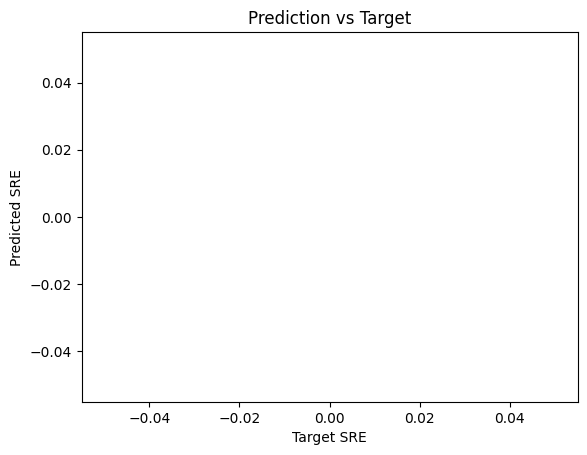

In [74]:
plt.figure()

plt.scatter(res_10q_100l["target"], res_10q_100l["prediction"], alpha=0.6)

# perfect prediction line
min_val = min(res_10q_100l["target"].min(), res_10q_100l["prediction"].min())
max_val = max(res_10q_100l["target"].max(), res_10q_100l["prediction"].max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("Target SRE")
plt.ylabel("Predicted SRE")
plt.title("Prediction vs Target")

plt.show()

In [75]:
def plot_error_vs_layers(df):
    grouped = df.groupby("n_layers")["error"].mean()

    plt.figure()
    plt.plot(grouped.index, grouped.values, marker="o")

    plt.xlabel("Number of layers")
    plt.ylabel("Mean error")
    plt.title("Error vs Layers")

    plt.show()

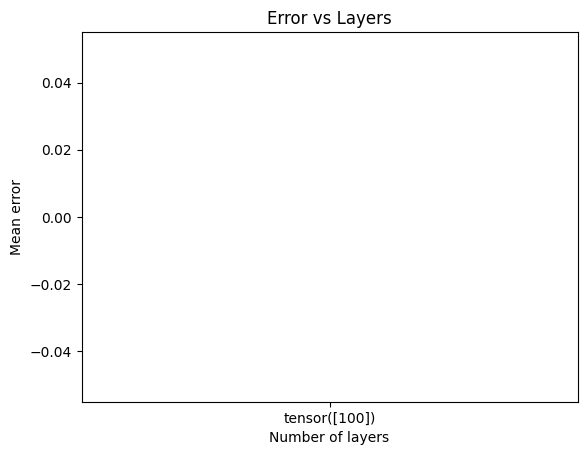

In [76]:
plot_error_vs_layers(res)

In [77]:
import numpy as np

y_true = res["target"].values
y_pred = res["prediction"].values
mask = (
    ~np.isnan(y_true) &
    ~np.isnan(y_pred) &
    ~np.isinf(y_true) &
    ~np.isinf(y_pred)
)

y_true_clean = y_true[mask]
y_pred_clean = y_pred[mask]
# baseline: always predict the mean of the target
y_mean = np.mean(y_true_clean)
y_baseline = np.full_like(y_true_clean, y_mean)

mse_model = np.mean((y_true_clean - y_pred_clean) ** 2)
mse_baseline = np.mean((y_true_clean - y_baseline) ** 2)

print("Model MSE:", mse_model)
print("Baseline MSE:", mse_baseline)
print("Improvement:", 1 - mse_model / mse_baseline)

Model MSE: 0.08330379120566697
Baseline MSE: 4.464769286083833
Improvement: 0.9813419718090888


In [78]:
print("Target std:", np.std(y_true_clean))
print("Prediction std:", np.std(y_pred_clean))

Target std: 2.113000067696126
Prediction std: 1.980955954302222


In [79]:
corr = np.corrcoef(y_true_clean, y_pred_clean)[0, 1]
print("Correlation:", corr)

Correlation: 0.9932180891723819
